In [13]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib scipy joblib streamlit


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [14]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [15]:
data = pd.read_csv('/Users/rajsingh/Cancer_prediction/lung cancer dataset (updated).csv')


In [16]:
data

,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Shortness of Breath,Wheezing,Swallowing Difficulty,Swallowing Difficulty.1,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level,Result
0,P1,33,Male,2,4.0,5,4.0,3,2,2,...,2,2,3,3,1,2,3,4,Low,1
1,P10,17,Male,3,1.0,5,3.0,4,2,2,...,7,8,6,6,2,1,7,2,Medium,0
2,P100,35,Male,4,5.0,6,5.0,5,4,6,...,9,2,1,1,4,6,7,2,High,1
3,P1000,37,Male,7,NaN,7,7.0,6,7,7,...,3,1,4,4,5,6,7,5,High,0
4,P101,46,Male,6,8.0,7,7.0,7,6,7,...,4,1,4,4,2,4,2,3,High,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,P995,44,Male,6,7.0,7,7.0,7,6,7,...,2,7,8,8,2,4,5,3,High,1
996,P996,37,Female,6,8.0,7,7.0,7,6,7,...,5,7,2,2,4,3,1,4,High,1
997,P997,25,Female,4,5.0,6,5.0,5,4,6,...,9,2,1,1,4,6,7,2,High,1
998,P998,18,Female,6,8.0,7,7.0,7,6,7,...,4,1,4,4,2,4,2,3,High,1


In [17]:
def create_lung_cancer_target(data):
    df = data.copy()

    # Risk Score Calculation
    df['Risk_Score'] = (
        # High Risk Factors
        (df['Smoking'] > 0).astype(int) * 3 +
        (df['Genetic Risk'] > 5).astype(int) * 3 +
        (df['chronic Lung Disease'] > 5).astype(int) * 3 +
        (df['OccuPational Hazards'] > 5).astype(int) * 3 +

        # Moderate Risk
        (df['Air Pollution'] > 5).astype(int) * 2 +
        (df['Alcohol use'] > 5).astype(int) * 2 +
        (df['Dust Allergy'] > 5).astype(int) * 2 +

        # Strong Symptoms
        (df['Shortness of Breath'] > 5).astype(int) * 4 +
        (df['Wheezing'] > 5).astype(int) * 4 +
        (df['Clubbing of Finger Nails'] > 5).astype(int) * 4 +
        (df['Dry Cough'] > 5).astype(int) * 4 +

        # Mild Symptoms
        (df['Frequent Cold'] > 5).astype(int) * 2 +
        (df['Snoring'] > 5).astype(int) * 2

        # Protective Factor
        - (df['Balanced Diet'] > 5).astype(int) * 2
    )

    # Define High Risk
    df['High_Risk'] = (df['Risk_Score'] >= 8).astype(int)

    return df

data = create_lung_cancer_target(data)
print(data['High_Risk'].value_counts())

High_Risk
1    621
0    379
Name: count, dtype: int64


In [18]:
data.isna().sum()[data.isna().sum() > 0]

Alcohol use             64
OccuPational Hazards    50
Obesity                 64
Smoking                 56
Smoking.1               56
Weight Loss             72
dtype: int64

In [19]:
from sklearn.impute import SimpleImputer

# Identify the columns with missing values (these were shown in cell irVJuz3IUVsP)
num_cols = ['Alcohol use', 'OccuPational Hazards', 'Obesity', 'Smoking', 'Smoking.1', 'Weight Loss']

# Numerical Imputer
num_imputer = SimpleImputer(strategy='median')

# Apply imputation to the 'data' DataFrame for the identified numerical columns
data[num_cols] = num_imputer.fit_transform(data[num_cols])

# Verify if there are any remaining missing values
print("Missing values after imputation:")
print(data.isna().sum()[data.isna().sum() > 0])

Missing values after imputation:
Series([], dtype: int64)


In [20]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = data.select_dtypes(include=['object']).columns

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    le_dict[col] = le

data.head()

,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Swallowing Difficulty,Swallowing Difficulty.1,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level,Result,Risk_Score,High_Risk
0,0,33,1,2,4.0,5,4.0,3,2,2,...,3,3,1,2,3,4,1,1,3,0
1,1,17,1,3,1.0,5,3.0,4,2,2,...,6,6,2,1,7,2,2,0,15,1
2,2,35,1,4,5.0,6,5.0,5,4,6,...,1,1,4,6,7,2,0,1,13,1
3,3,37,1,7,5.0,7,7.0,6,7,7,...,4,4,5,6,7,5,0,0,20,1
4,4,46,1,6,8.0,7,7.0,7,6,7,...,4,4,2,4,2,3,0,0,16,1


In [21]:
X = data.drop(columns=['Patient Id', 'High_Risk'])
y = data['High_Risk']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1000, 28)
Target Shape: (1000,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

Train Size: (800, 28)
Test Size: (200, 28)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [25]:
y_pred = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)[:, 1]

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.99

Confusion Matrix:
[[ 74   2]
 [  0 124]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        76
           1       0.98      1.00      0.99       124

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



Matplotlib is building the font cache; this may take a moment.


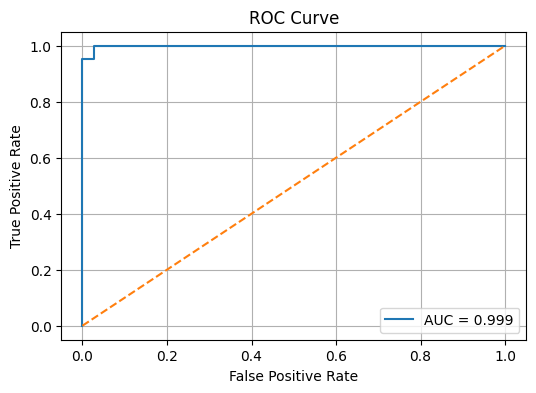

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import make_scorer, fbeta_score
import numpy as np

In [29]:
f2_scorer = make_scorer(fbeta_score, beta=2)
param_distributions = {
    'C': loguniform(0.01, 10),     # Stable range
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000, 2000]
}
random_search_lr = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring=f2_scorer,   # ✅ Balanced recall optimization
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Starting Logistic Regression Tuning...")
random_search_lr.fit(X_train, y_train)

Starting Logistic Regression Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,LogisticRegre...ndom_state=42)
,param_distributions,"{'C': <scipy.stats....t 0x119cbb7c0>, 'class_weight': [None, 'balanced'], 'max_iter': [1000, 2000], 'penalty': ['l1', 'l2'], ...}"
,n_iter,50
,scoring,"make_scorer(f...dict', beta=2)"
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [30]:
print("\nBest Parameters:")
print(random_search_lr.best_params_)

print("\nBest Cross-Validation F2 Score:")
print(random_search_lr.best_score_)
best_lr_model = random_search_lr.best_estimator_

y_pred_tuned = best_lr_model.predict(X_test)
y_proba_tuned = best_lr_model.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))


Best Parameters:
{'C': np.float64(2.6443593078398644), 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}

Best Cross-Validation F2 Score:
0.9991975725967419

Accuracy: 1.0

Confusion Matrix:
[[ 76   0]
 [  0 124]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        76
           1       1.00      1.00      1.00       124

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [32]:
import joblib

# Save model
joblib.dump(best_lr_model, "lung_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature names
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']